In [1]:
from ase.build import bulk
from atomistics.calculators import (
    calc_molecular_dynamics_phonons_with_lammpslib,
    evaluate_with_lammpslib,
    get_potential_by_name
)
from atomistics.workflows import (
    optimize_positions_and_volume,
    get_tasks_for_harmonic_approximation,
    analyse_results_for_harmonic_approximation,
)
from dynaphopy import Quasiparticle
import pandas
from phonopy.units import VaspToTHz
import spglib

from HelpfulFunctions import equilibriate_structure_at_finite_temperature



/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-12-08/lib/python3.12/site-packages/atomistics/calculators/__init__.py:63: UserWarning: calc_static_with_qe(), evaluate_with_qe() and optimize_positions_and_volume_with_qe() are not available as the import of the module named 'pwtools' failed.
  raise_warning(module_list=quantum_espresso_function, import_error=e)


# Function Definitions

In [2]:
import ase
def create_vacancy(Structure:ase.Atoms,
                  index:int=0)->ase.Atoms:
    NewStructure = Structure.copy()
    del NewStructure[index]
    return NewStructure

In [3]:
from typing import Optional, Any
def plot_dos(
    phonopy_dict: dict,
    *args,
    axis: Optional[Any] = None,
    **kwargs,
):
    """
    Plot the DOS.

    If "label" is present in `kwargs` a legend is added to the plot automatically.

    Args:
        phonopy_dict (dict): The calculated phonon properties.
        axis (optional): matplotlib axis to use, if None create a new one
        *args: passed to `axis.plot`
        **kwargs: passed to `axis.plot`

    Returns:
        matplotlib.axes._subplots.AxesSubplot: axis with the plot
    """
    import matplotlib.pyplot as plt

    dos_energies = phonopy_dict["total_dos_dict"]["frequency_points"]
    dos_total = phonopy_dict["total_dos_dict"]["total_dos"]
    dos_norm = sum(dos_total)
    if axis is None:
        _, axis = plt.subplots(1, 1)
    axis.plot(dos_energies, dos_total/dos_norm, *args, **kwargs)
    axis.set_xlabel("Frequency [THz]")
    axis.set_ylabel("DOS")
    axis.set_title("Phonon DOS vs Energy")
    if "label" in kwargs:
        axis.legend()
    return axis

In [4]:
import ase
import numpy as np

def insert_interstitial(Structure: ase.Atoms, 
                       position: np.ndarray = None,
                       element: str = None,
                       site_type: str = 'tetrahedral') -> ase.Atoms:
    from pyiron import ase_to_pyiron
    """
    Insert an interstitial atom into the structure.
    
    Parameters:
    -----------
    Structure : ase.Atoms
        The atomic structure
    position : np.ndarray, optional
        Cartesian coordinates for the interstitial. If None, uses site_type.
    element : str, optional
        Element symbol for interstitial. If None, uses same element as Structure[0]
    site_type : str, optional
        Type of interstitial site ('tetrahedral' or 'octahedral') for diamond/fcc structures.
        Only used if position is None.
    
    Returns:
    --------
    ase.Atoms
        Structure with interstitial added
    """
    
    if element is None:
        element = Structure[0].symbol
    
    if position is None:
        # For diamond cubic (like Si), calculate tetrahedral or octahedral site
        cell = Structure.cell.array
        
        if site_type == 'tetrahedral':
            # Tetrahedral site in diamond cubic: (1/4, 1/4, 1/4) in fractional coords
            position = 0.25 * (cell[0] + cell[1] + cell[2])
        elif site_type == 'octahedral':
            # Octahedral site: (1/2, 1/2, 1/2) in fractional coords
            position = 0.5 * (cell[0] + cell[1] + cell[2])
        else:
            raise ValueError("site_type must be 'tetrahedral' or 'octahedral'")
    
    # Add the interstitial atom
    interstitial = ase.Atom(element, position=position)
    NewStructure = Structure.copy()
    NewStructure.append(interstitial)
    
    return ase_to_pyiron(NewStructure)

In [5]:
import numpy as np
def GetPhononBands(Structure,
                  InteratomicPotential:str,
                    Temperature:int=0,
                   SuperCellDimensions:list[int] = [2,2,2],
                   band_path = None, #['GAMMA', 'X', 'U', 'K', 'GAMMA', 'L', 'W', 'X']
                  primitive_matrix=None):
    
    from ase.build import bulk
    from atomistics.calculators import (
        calc_molecular_dynamics_phonons_with_lammpslib,
        evaluate_with_lammpslib,
        get_potential_by_name
    )
    from atomistics.workflows import (
        optimize_positions_and_volume,
        get_tasks_for_harmonic_approximation,
        analyse_results_for_harmonic_approximation,
    )
    from dynaphopy import Quasiparticle
    import pandas
    from phonopy.units import VaspToTHz
    import spglib
    import numpy as np
    
    from HelpfulFunctions import equilibriate_structure_at_finite_temperature
    
    potential_dataframe = get_potential_by_name(potential_name="1988--Tersoff-J--Si-c--LAMMPS--ipr1"
                                               )
    if Temperature:
        structure_ase = equilibriate_structure_at_finite_temperature(
                                                                    structure=Structure,
                                                                    potential=potential_dataframe['Name'], 
                                                                    temperature=Temperature, 
                                                                    seed=4535,
                                                                    cell_scale_value=1
                                                                )
    else:
        task_dict = optimize_positions_and_volume(structure=Structure
                                                 )
        result_dict = evaluate_with_lammpslib(task_dict=task_dict,
                                              potential_dataframe=potential_dataframe
                                             )
        
        structure_ase = result_dict["structure_with_optimized_positions_and_volume"]

    cell = (
        structure_ase.cell.array,
        structure_ase.get_scaled_positions(),
        structure_ase.numbers,
    )
    # if primitive_matrix !=np.eye(3):
    #     primitive_matrix = spglib.standardize_cell(cell=cell, to_primitive=True)[
    #        0
    #     ] / structure_ase.get_volume() ** (1 / 3)
    
    task_dict, phonopy_obj = get_tasks_for_harmonic_approximation(
        structure=structure_ase,
        interaction_range=10,
        factor=VaspToTHz,
        displacement=0.01,
        primitive_matrix=primitive_matrix,
        number_of_snapshots=None,
    )
    result_dict = evaluate_with_lammpslib(
        task_dict=task_dict,
        potential_dataframe=potential_dataframe,
    )
    phonopy_dict = analyse_results_for_harmonic_approximation(
        phonopy=phonopy_obj,
        output_dict=result_dict,
        dos_mesh=20,
        number_of_snapshots=None,
    )
    if not Temperature:
        Temperature = 300 # Previously 600 K

    trajectory = calc_molecular_dynamics_phonons_with_lammpslib(
                                                                structure_ase=structure_ase,
                                                                potential_dataframe=potential_dataframe,
                                                                force_constants=phonopy_obj.force_constants,
                                                                phonopy_unitcell=phonopy_obj.unitcell,
                                                                phonopy_primitive_matrix=phonopy_obj.primitive_matrix,
                                                                phonopy_supercell_matrix=phonopy_obj.supercell_matrix,
                                                                total_time=2,  # ps
                                                                time_step=0.001,  # ps
                                                                relaxation_time=5,  # ps
                                                                silent=True,
                                                                supercell=SuperCellDimensions,
                                                                memmap=False,
                                                                velocity_only=True,
                                                                temperature=Temperature,
                                                            )

    Q_vectors = {
                'GAMMA':[0.0, 0.0, 0.0],
                'X':[0.5, 0.0, 0.5],
                'U':[0.625, 0.25, 0.625],
                'K':[0.375, 0.375, 0.75],
                'L':[0.5, 0.5, 0.5],
                'W':[0.5, 0.25, 0.75],
                'R':[0.5,0.0,0.0]
                }

    
    calculation = Quasiparticle(trajectory)
    
    # if band_path:
    #     calculation.set_band_ranges([ [Q_vectors.get(band_path[0]), Q_vectors.get(band_path[1])],
    #                               [Q_vectors.get(band_path[1]), Q_vectors.get(band_path[2])],
    #                               [Q_vectors.get(band_path[2]), Q_vectors.get(band_path[3])],
    #                               [Q_vectors.get(band_path[3]), Q_vectors.get(band_path[4])],
    #                               [Q_vectors.get(band_path[4]), Q_vectors.get(band_path[5])],
    #                               [Q_vectors.get(band_path[5]), Q_vectors.get(6)]
    #                             ])
        ## Needs work with the labels
    
    calculation.select_power_spectra_algorithm(2)  # select FFT algorithm
    calculation.get_renormalized_phonon_dispersion_bands()
    renormalized_force_constants = (
        calculation.get_renormalized_force_constants().get_array()
    )
    #renormalized_force_constants
    
    #calculation.plot_renormalized_phonon_dispersion_bands()

    return trajectory, calculation, phonopy_dict, phonopy_obj

# Unit Cell

In [6]:
structure_bulk = bulk("Si", cubic=True)
potential_name="1988--Tersoff-J--Si-c--LAMMPS--ipr1"

In [7]:
trajectory, calculation, phonopy_dict, phonopy_obj = GetPhononBands(Structure=structure_bulk, InteratomicPotential=potential_name)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 21.200000000000003

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-4.13122059e-06 -4.12974343e-06 -4.12620573e-06  6.89533567e+00
  6.89533567e+00  6.89533567e+00  6.89533567e+00  6.89533567e+00
  6.89533567e+00  1.21917904e+01  1.21917904e+01  1.21917904e+01
  1.21917904e+01  1.21917904e+01  1.21917904e+01  1.48909552e+01
  1.48909552e+01  1.48909552e+01  1.48909552e+01  1.48909552e+01
  1.48909552e+01  1.60678991e+01  1.60678991e+01  1.60678991e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width                             0.495806 T

In [8]:
structure_vacancy = create_vacancy(Structure=structure_bulk)

In [9]:
trajectory_vacancy, calculation_vacancy, phonopy_dict_vacancy, phonopy_obj_vacancy = GetPhononBands(Structure=structure_vacancy, InteratomicPotential=potential_name)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 21.400000000000002

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-3.63711978e-04 -3.63711835e-04 -3.63711746e-04  5.24331665e+00
  5.24331665e+00  5.24331665e+00  6.44993422e+00  6.44993422e+00
  6.44993422e+00  7.61398888e+00  1.18901824e+01  1.18901824e+01
  1.26631241e+01  1.26631241e+01  1.26631241e+01  1.50172267e+01
  1.50172267e+01  1.50172267e+01  1.61885967e+01  1.61885967e+01
  1.61885967e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width                             0.745860 THz
Position                          5.118243 TH

In [10]:
structure_interstitial = insert_interstitial(structure_bulk, site_type='octahedral')

In [11]:
trajectory_interstitial, calculation_interstitial, phonopy_dict_interstitial, phonopy_obj_interstitial = GetPhononBands(Structure=structure_interstitial, InteratomicPotential=potential_name)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 40.45

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-1.00491713e-02 -1.00491713e-02 -1.00491713e-02  5.35975927e+00
  5.35975927e+00  5.35975927e+00  6.45369754e+00  6.45369754e+00
  6.45369754e+00  7.55807502e+00  7.55807502e+00  7.55807502e+00
  9.11013903e+00  9.11013903e+00  9.48918300e+00  9.48918300e+00
  9.48918300e+00  9.79022949e+00  9.79022949e+00  9.79022949e+00
  1.02546981e+01  1.18739142e+01  1.18739142e+01  1.18739142e+01
  3.06690063e+01  3.06690063e+01  3.06690063e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width   

## Ground state - 0K

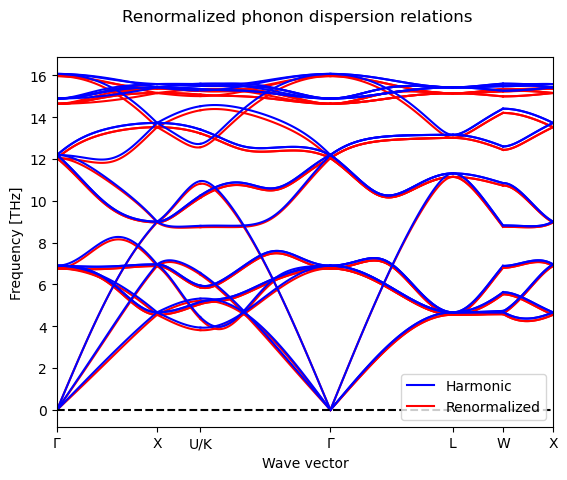

In [12]:
calculation.plot_renormalized_phonon_dispersion_bands()

## Vacancy ~ 12% 0K

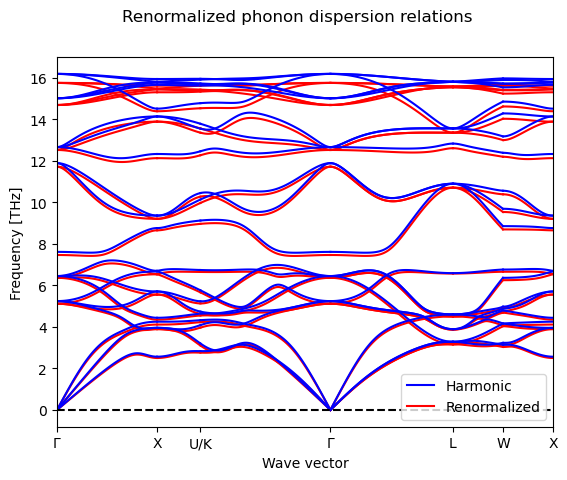

In [13]:
calculation_vacancy.plot_renormalized_phonon_dispersion_bands()

## Interstitial ~11% 0K

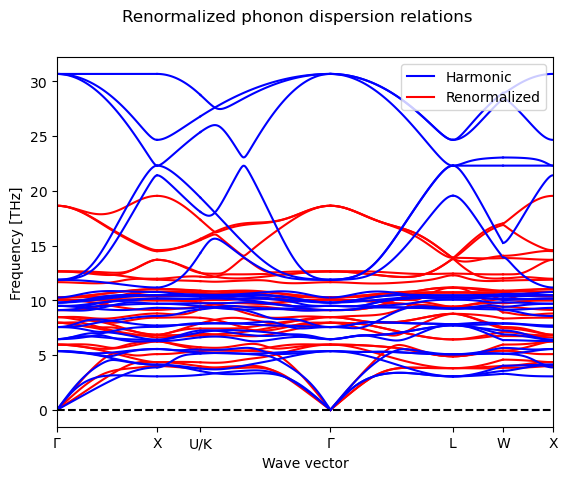

In [14]:
calculation_interstitial.plot_renormalized_phonon_dispersion_bands()

## Vacancy ~12% 300K

In [15]:
trajectory_vacancy_300, calculation_vacancy_300, phonopy_dict_vacancy_300, phonopy_obj_vacancy_300 = GetPhononBands(Structure=structure_vacancy, InteratomicPotential=potential_name, Temperature=300)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 22.700000000000003

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-2.58657885e-04 -2.07316611e-04 -1.89479434e-04  4.80782555e+00
  4.99590762e+00  5.29067602e+00  6.30583068e+00  6.39718463e+00
  6.43583290e+00  7.46778663e+00  1.14794143e+01  1.16340446e+01
  1.21425608e+01  1.25021784e+01  1.27728984e+01  1.42978515e+01
  1.45031250e+01  1.52916523e+01  1.60679620e+01  1.65234559e+01
  1.72067952e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width                             0.467658 THz
Position                          0.033414 TH

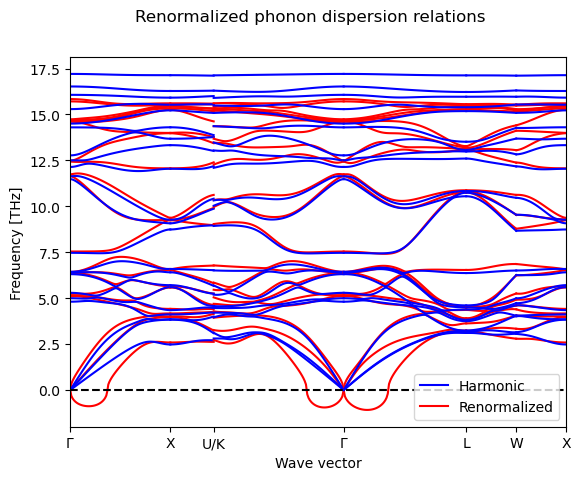

In [16]:
calculation_vacancy_300.plot_renormalized_phonon_dispersion_bands()

## Interstitial ~11% 300K

In [17]:
trajectory_interstitial_300, calculation_interstitial_300, phonopy_dict_interstitial_300, phonopy_obj_interstitial_300 = GetPhononBands(Structure=structure_interstitial, InteratomicPotential=potential_name, Temperature=300)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 38.85

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-2.35282341e-03 -1.99945646e-03 -5.39224285e-04  4.83839722e+00
  5.23220112e+00  5.59245219e+00  5.69827276e+00  6.21319436e+00
  6.60762241e+00  7.24232615e+00  7.48119196e+00  7.88022683e+00
  8.51042518e+00  8.73158701e+00  9.25817949e+00  9.83860272e+00
  1.00707338e+01  1.06155737e+01  1.12990280e+01  1.17404140e+01
  1.33142767e+01  1.36661819e+01  1.46969535e+01  1.57524217e+01
  1.59573260e+01  2.51919106e+01  2.94083313e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width   

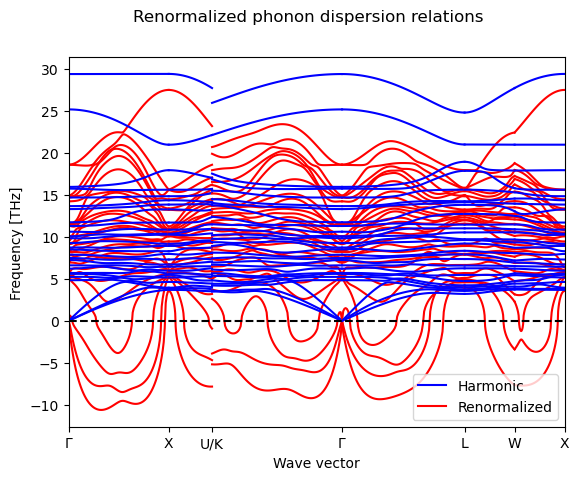

In [18]:
calculation_interstitial_300.plot_renormalized_phonon_dispersion_bands()

# Supercell 2x2x2

In [19]:
from pyiron import ase_to_pyiron
structure_bulk222 = ase_to_pyiron(bulk("Si", cubic=True)).repeat([2,2,2])
potential_name="1988--Tersoff-J--Si-c--LAMMPS--ipr1"

In [20]:
structure_bulk222_vacancy = create_vacancy(structure_bulk222)

In [21]:
trajectory_bulk222, calculation__bulk222, phonopy_dict_bulk222, phonopy_obj__bulk222 = GetPhononBands(Structure=structure_bulk222, InteratomicPotential=potential_name)
trajectory_bulk222_vacancy, calculation__bulk222_vacancy, phonopy_dict_bulk222_vacancy, phonopy_obj__bulk222_vacancy = GetPhononBands(Structure=structure_bulk222_vacancy, InteratomicPotential=potential_name)

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 21.200000000000003

Q-point: 1 / 1     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[2.64168626e-06 2.65143851e-06 2.65962606e-06 4.66397327e+00
 4.66397327e+00 4.66397327e+00 4.66397327e+00 4.66397327e+00
 4.66397327e+00 4.66397327e+00 4.66397327e+00 4.66397327e+00
 4.66397327e+00 4.66397327e+00 4.66397327e+00 4.66787904e+00
 4.66787904e+00 4.66787904e+00 4.66787904e+00 4.66787904e+00
 4.66787904e+00 4.66787904e+00 4.66787904e+00 4.66787904e+00
 4.66787904e+00 4.66787904e+00 4.66787904e+00 4.66787904e+00
 4.66787904e+00 4.66787904e+00 4.66787904e+00 4.66787904e+00
 4.66787904e+00 4.66787904e+00 4.66787904e+00 6.89533567e+00
 6.89533567e+00 6.89533567e+00 6.89533567e+00 6.89533567e+00
 6.89533567e+00 6.89816884e+00 6.89816884e+00 6.89816884e+00
 6.89816884e+00 6.89816884e+00 6.89816884e+00 6.96109048e+00
 6.96109048e+00 6.96109048e+00 6.96109048e+00 6.96109048e+00
 6.96109048e+00 6.96

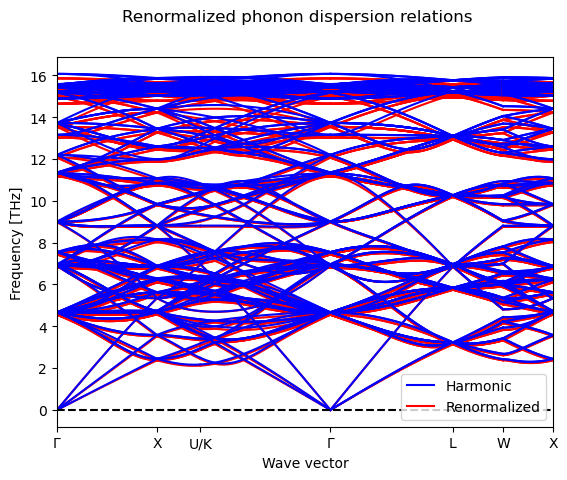

In [22]:
calculation__bulk222.plot_renormalized_phonon_dispersion_bands()

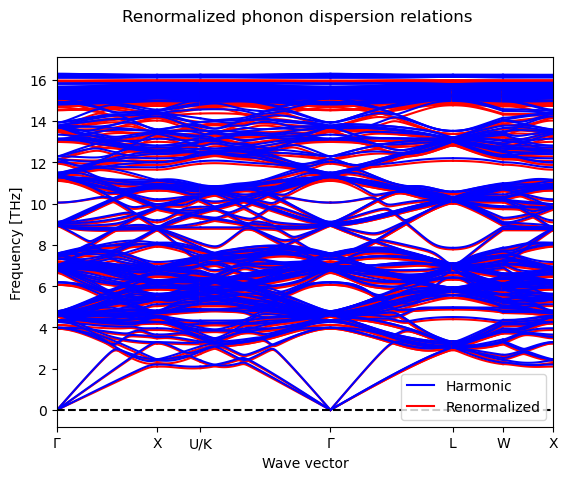

In [23]:
calculation__bulk222_vacancy.plot_renormalized_phonon_dispersion_bands()

In [24]:
a, b = phonopy_obj.get_frequencies_with_eigenvectors([0.0,0.0,0.0])

In [25]:
b.shape

(24, 24)

In [26]:
a

array([-4.13122059e-06, -4.12974343e-06, -4.12620573e-06,  6.89533567e+00,
        6.89533567e+00,  6.89533567e+00,  6.89533567e+00,  6.89533567e+00,
        6.89533567e+00,  1.21917904e+01,  1.21917904e+01,  1.21917904e+01,
        1.21917904e+01,  1.21917904e+01,  1.21917904e+01,  1.48909552e+01,
        1.48909552e+01,  1.48909552e+01,  1.48909552e+01,  1.48909552e+01,
        1.48909552e+01,  1.60678991e+01,  1.60678991e+01,  1.60678991e+01])

In [27]:
b

array([[ 3.09232220e-01+0.j, -1.16410215e-01+0.j, -1.25793862e-01-0.j,
         3.23187316e-01+0.j, -1.12387307e-01+0.j, -3.55442343e-01+0.j,
         6.59620489e-02+0.j, -4.71618074e-02+0.j, -2.13650280e-03+0.j,
         4.92228033e-01+0.j,  5.82463409e-02+0.j,  2.73218364e-03+0.j,
        -7.18379315e-03+0.j,  6.52675656e-02+0.j,  1.57051693e-05+0.j,
        -3.73518345e-01+0.j,  2.59372193e-01+0.j,  1.95262873e-01+0.j,
        -1.70316590e-02+0.j, -2.66898037e-02+0.j,  6.38756525e-02+0.j,
        -3.53132925e-01+0.j, -1.81174816e-03+0.j,  1.71421927e-02+0.j],
       [ 1.53115688e-01+0.j,  3.04232877e-01+0.j,  9.48574865e-02+0.j,
        -2.02384125e-01+0.j, -5.33595303e-02+0.j, -1.45458229e-01+0.j,
        -5.91684773e-02+0.j, -2.29965553e-01+0.j, -3.58678499e-01+0.j,
        -1.92166023e-02+0.j,  3.02362089e-01+0.j, -3.52693450e-01+0.j,
        -1.08379581e-01+0.j, -1.22053858e-01+0.j, -8.46873179e-02+0.j,
         2.04533831e-01+0.j,  2.92754433e-01+0.j, -6.52802339e-02+0.j,
     

In [28]:
trajectory, calculation, phonopy_dict, phonopy_obj = GetPhononBands(Structure=structure_bulk, InteratomicPotential=potential_name,
                                                                   primitive_matrix=np.eye(3))

Using 2000 steps
Using Fast Fourier transform (Numpy) function
set frequency range: 0.0 - 21.200000000000003

Q-point: 1 / 8     [ 0.00000  0.00000  0.00000 ]
Harmonic frequencies (THz):
[-4.13122059e-06 -4.12974343e-06 -4.12620573e-06  6.89533567e+00
  6.89533567e+00  6.89533567e+00  6.89533567e+00  6.89533567e+00
  6.89533567e+00  1.21917904e+01  1.21917904e+01  1.21917904e+01
  1.21917904e+01  1.21917904e+01  1.21917904e+01  1.48909552e+01
  1.48909552e+01  1.48909552e+01  1.48909552e+01  1.48909552e+01
  1.48909552e+01  1.60678991e+01  1.60678991e+01  1.60678991e+01]
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
MD cell size relation: [2 2 2]
Power spectrum resolution requested unavailable, using maximum:  0.500000 THz
If you need higher resolution increase the number of data
FFT: [##############################] 100.00% Done...

Peak # 1
----------------------------------------------
Width                             0.495806 T

In [29]:
a2, b2 = phonopy_obj.get_frequencies_with_eigenvectors([0.0,0.0,0.0])

In [30]:
phonopy_obj.get_frequencies_with_eigenvectors??

Signature: phonopy_obj.get_frequencies_with_eigenvectors(q: 'ArrayLike') -> 'tuple[NDArray, NDArray]'
Source:   
    def get_frequencies_with_eigenvectors(
        self, q: ArrayLike
    ) -> tuple[NDArray, NDArray]:
        """Calculate phonon frequencies and eigenvectors at a given q-point.

        Parameters
        ----------
        q: array_like
            A q-vector.
            shape=(3,)

        Returns
        -------
        (frequencies, eigenvectors)

        frequencies: ndarray
            Phonon frequencies. Imaginary frequenies are represented by
            negative real numbers.
            shape=(bands, ), dtype='double', order='C'
        eigenvectors: ndarray
            Phonon eigenvectors.
            shape=(bands, bands)
            dtype=complex of "c%d" % (np.dtype('double').itemsize * 2)
            order='C'

        """
        self._set_dynamical_matrix()
        if self._dynamical_matrix is None:
            msg = "Dynamical matrix has not yet built."

In [31]:
b2.shape

(24, 24)

In [32]:
structure_bulk

Atoms(symbols='Si8', pbc=True, cell=[5.43, 5.43, 5.43])

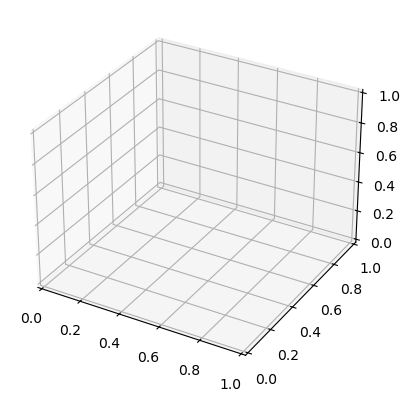

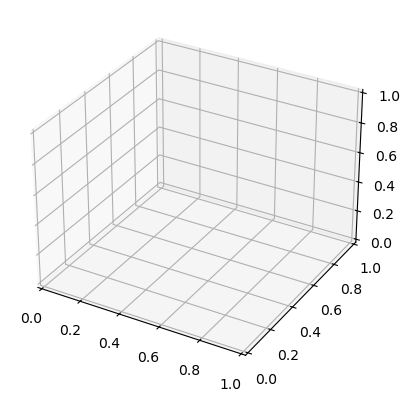

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Alternative way
fig = plt.figure()
ax = plt.axes(projection='3d')


In [35]:
a2, b2 = phonopy_obj.get_frequencies_with_eigenvectors([0.0,0.0,0.0])

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to visualize a specific mode
def plot_mode(structure, displacement_data, mode_index, scale_factor=1.0):
    """
    Plot atomic positions with displacement vectors for a specific mode
    
    structure: ase.Atoms object
    displacement_data: displacement matrix from phonopy
    mode_index: which row of the displacement matrix to visualize (0-23)
    scale_factor: scaling for the arrows to make them visible
    """
    # Get positions and number of atoms from structure
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Since the values are complex but imaginary parts are 0, take real part
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    # Extract the mode (row) and reshape to (n_atoms, 3 components)
    mode = displacement_data[mode_index].reshape(n_atoms, 3)
    
    # Scale the displacements for visualization
    scaled_displacements = mode * scale_factor
    
    # Create figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot atoms
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c='blue', s=200, alpha=0.8, edgecolors='black', linewidth=2,
               label='Atoms')
    
    # Plot displacement vectors
    ax.quiver(points[:, 0], points[:, 1], points[:, 2],
              scaled_displacements[:, 0], 
              scaled_displacements[:, 1], 
              scaled_displacements[:, 2],
              color='red', arrow_length_ratio=0.2, linewidth=2, alpha=0.7,
              label=f'Mode {mode_index}')
    
    # Add atom labels
    for i, pos in enumerate(points):
        ax.text(pos[0], pos[1], pos[2], f'  {i}', fontsize=10)
    
    # Set labels and title
    ax.set_xlabel('X (Å)', fontsize=12)
    ax.set_ylabel('Y (Å)', fontsize=12)
    ax.set_zlabel('Z (Å)', fontsize=12)
    ax.set_title(f'Displacement Mode {mode_index}', fontsize=14)
    
    # Set equal aspect ratio
    max_range = np.array([points[:, 0].max()-points[:, 0].min(),
                          points[:, 1].max()-points[:, 1].min(),
                          points[:, 2].max()-points[:, 2].min()]).max() / 2.0
    
    mid_x = (points[:, 0].max()+points[:, 0].min()) * 0.5
    mid_y = (points[:, 1].max()+points[:, 1].min()) * 0.5
    mid_z = (points[:, 2].max()+points[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range*1.2, mid_x + max_range*1.2)
    ax.set_ylim(mid_y - max_range*1.2, mid_y + max_range*1.2)
    ax.set_zlim(mid_z - max_range*1.2, mid_z + max_range*1.2)
    
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()
    
    return fig, ax

# Interactive version using Plotly
def plot_mode_interactive(structure, displacement_data, mode_index, scale_factor=1.0):
    """
    Interactive plot using Plotly
    """
    import plotly.graph_objects as go
    
    # Get positions and number of atoms from structure
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Handle complex data
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    # Extract and scale the mode
    mode = displacement_data[mode_index].reshape(n_atoms, 3) * scale_factor
    
    fig = go.Figure()
    
    # Add atoms
    fig.add_trace(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode='markers+text',
        marker=dict(size=12, color='blue', line=dict(color='black', width=2)),
        text=[f'Atom {i}' for i in range(n_atoms)],
        textposition='top center',
        name='Atoms'
    ))
    
    # Add displacement vectors as lines with cones
    for i in range(n_atoms):
        # End point of arrow
        end_point = points[i] + mode[i]
        
        # Arrow shaft
        fig.add_trace(go.Scatter3d(
            x=[points[i, 0], end_point[0]],
            y=[points[i, 1], end_point[1]],
            z=[points[i, 2], end_point[2]],
            mode='lines',
            line=dict(color='red', width=5),
            showlegend=(i==0),
            name='Displacement' if i==0 else None
        ))
        
        # Arrow head (cone)
        if np.linalg.norm(mode[i]) > 0.01:  # Only add cone if displacement is significant
            fig.add_trace(go.Cone(
                x=[end_point[0]], y=[end_point[1]], z=[end_point[2]],
                u=[mode[i, 0]], v=[mode[i, 1]], w=[mode[i, 2]],
                sizeref=0.3,
                showscale=False,
                colorscale=[[0, 'red'], [1, 'red']],
                showlegend=False
            ))
    
    fig.update_layout(
        title=f'Displacement Mode {mode_index}',
        scene=dict(
            xaxis_title='X (Å)',
            yaxis_title='Y (Å)',
            zaxis_title='Z (Å)',
            aspectmode='cube'
        ),
        width=1000,
        height=800
    )
    
    fig.show()
    
    return fig

# Function to animate through all modes
def animate_modes(structure, displacement_data, scale_factor=1.0, interval=1000):
    """
    Animate through all displacement modes
    """
    from matplotlib.animation import FuncAnimation
    
    # Get positions and number of atoms
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Handle complex data
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    n_modes = displacement_data.shape[0]
    
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    def update(frame):
        ax.clear()
        
        # Extract mode
        mode = displacement_data[frame].reshape(n_atoms, 3) * scale_factor
        
        # Plot atoms
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                   c='blue', s=200, alpha=0.8, edgecolors='black', linewidth=2)
        
        # Plot displacement vectors
        ax.quiver(points[:, 0], points[:, 1], points[:, 2],
                  mode[:, 0], mode[:, 1], mode[:, 2],
                  color='red', arrow_length_ratio=0.2, linewidth=2, alpha=0.7)
        
        ax.set_xlabel('X (Å)')
        ax.set_ylabel('Y (Å)')
        ax.set_zlabel('Z (Å)')
        ax.set_title(f'Mode {frame}')
        
        # Set limits based on actual structure
        max_range = np.array([points[:, 0].max()-points[:, 0].min(),
                              points[:, 1].max()-points[:, 1].min(),
                              points[:, 2].max()-points[:, 2].min()]).max() / 2.0
        
        mid_x = (points[:, 0].max()+points[:, 0].min()) * 0.5
        mid_y = (points[:, 1].max()+points[:, 1].min()) * 0.5
        mid_z = (points[:, 2].max()+points[:, 2].min()) * 0.5
        
        ax.set_xlim(mid_x - max_range*1.2, mid_x + max_range*1.2)
        ax.set_ylim(mid_y - max_range*1.2, mid_y + max_range*1.2)
        ax.set_zlim(mid_z - max_range*1.2, mid_z + max_range*1.2)
    
    ani = FuncAnimation(fig, update, frames=n_modes, interval=interval, repeat=True)
    plt.show()
    
    return ani

# Example usage:
# from ase import Atoms
# structure = Atoms(...)  # your ASE structure
# displacement_data = ...  # your displacement data from phonopy
# 
# fig, ax = plot_mode(structure, displacement_data, mode_index=0, scale_factor=2.0)
# plot_mode_interactive(structure, displacement_data, mode_index=0, scale_factor=2.0)
# ani = animate_modes(structure, displacement_data, scale_factor=2.0)

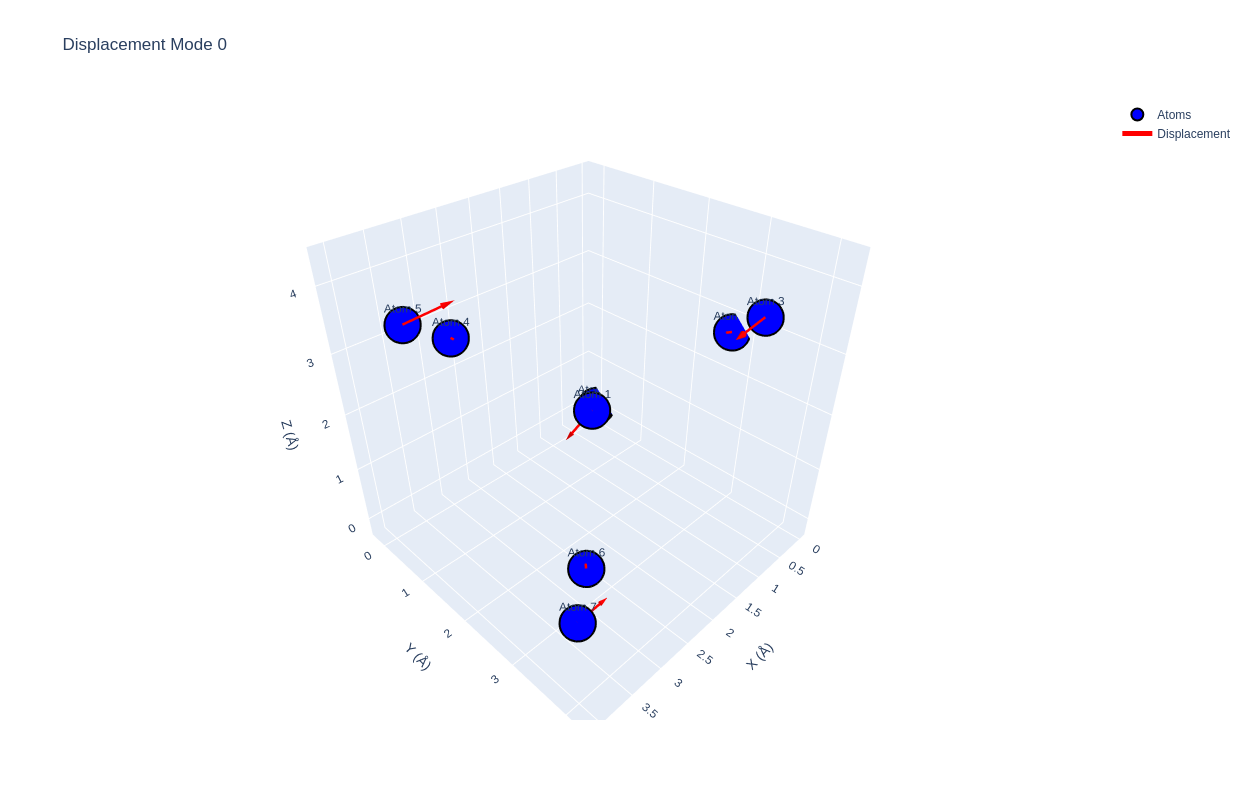

In [37]:
plot_mode_interactive(structure=structure_bulk, displacement_data=b2.copy(), mode_index=0);

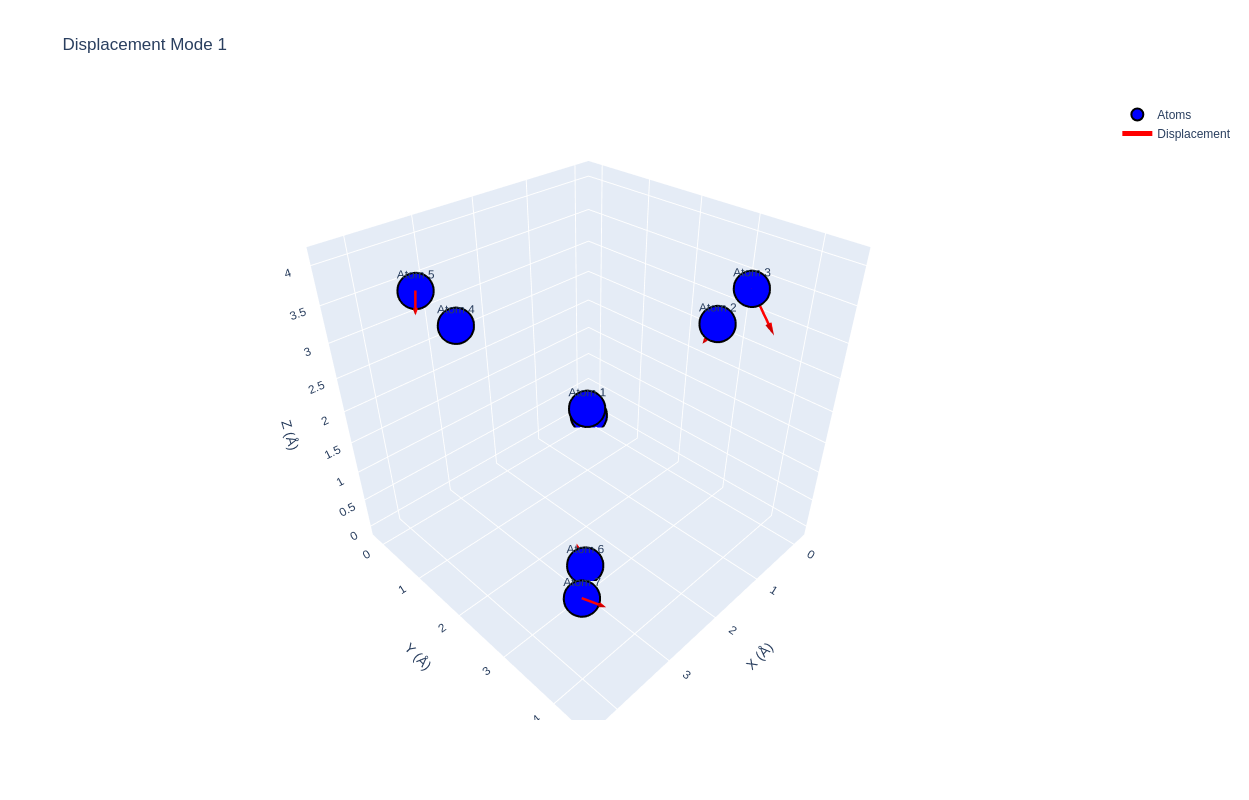

In [38]:
plot_mode_interactive(structure=structure_bulk, displacement_data=b2.copy(), mode_index=1);

In [39]:
a2_vacancy, b2_vacancy = phonopy_obj_vacancy.get_frequencies_with_eigenvectors([0.0,0.0,0.0])
# ani = animate_modes(structure=structure_bulk, displacement_data=b2.copy(), scale_factor=2.0)

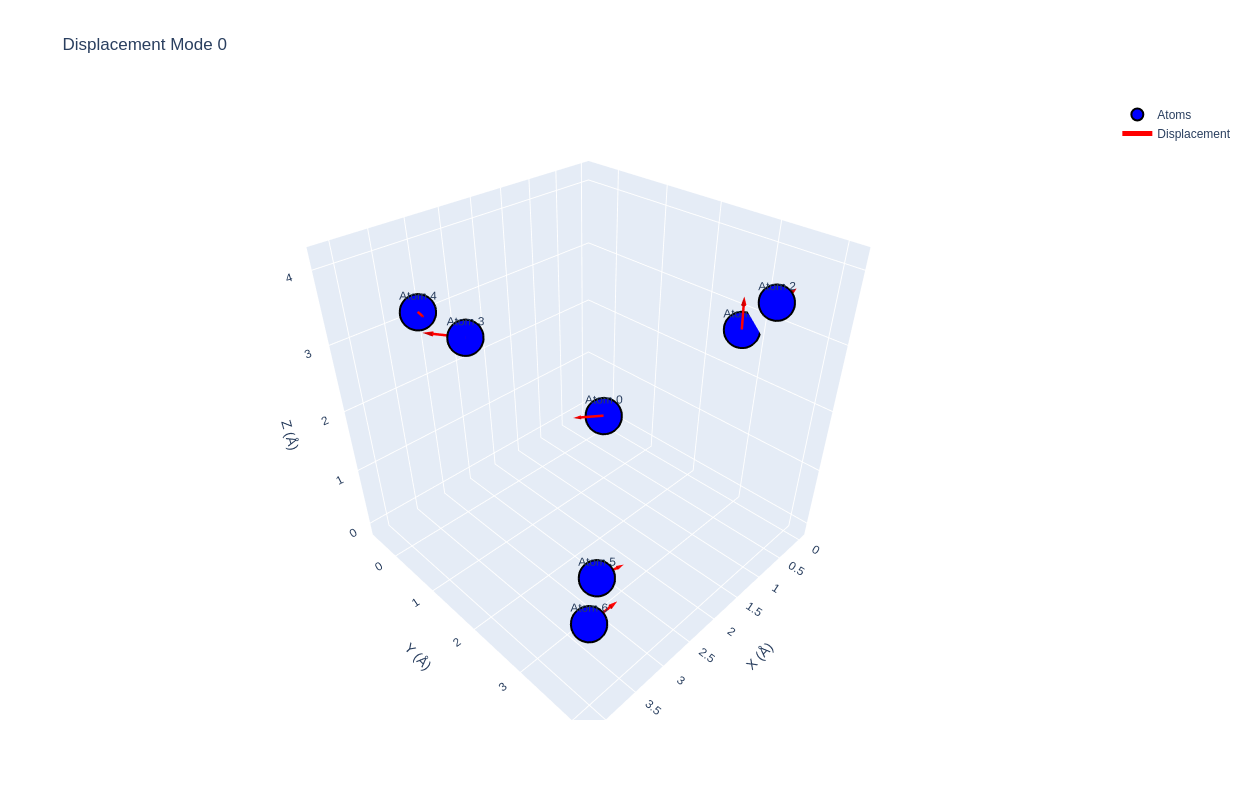

In [40]:
plot_mode_interactive(structure=structure_vacancy, displacement_data=b2_vacancy.copy(), mode_index=0);

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to visualize a specific mode
def plot_mode(structure, displacement_data, mode_index, scale_factor=1.0):
    """
    Plot atomic positions with displacement vectors for a specific mode
    
    structure: ase.Atoms object
    displacement_data: displacement matrix from phonopy
    mode_index: which row of the displacement matrix to visualize (0-23)
    scale_factor: scaling for the arrows to make them visible
    """
    # Get positions and number of atoms from structure
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Since the values are complex but imaginary parts are 0, take real part
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    # Extract the mode (row) and reshape to (n_atoms, 3 components)
    mode = displacement_data[mode_index].reshape(n_atoms, 3)
    
    # Scale the displacements for visualization
    scaled_displacements = mode * scale_factor
    
    # Create figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot atoms
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c='blue', s=200, alpha=0.8, edgecolors='black', linewidth=2,
               label='Atoms')
    
    # Plot displacement vectors
    ax.quiver(points[:, 0], points[:, 1], points[:, 2],
              scaled_displacements[:, 0], 
              scaled_displacements[:, 1], 
              scaled_displacements[:, 2],
              color='red', arrow_length_ratio=0.2, linewidth=2, alpha=0.7,
              label=f'Mode {mode_index}')
    
    # Add atom labels
    for i, pos in enumerate(points):
        ax.text(pos[0], pos[1], pos[2], f'  {i}', fontsize=10)
    
    # Set labels and title
    ax.set_xlabel('X (Å)', fontsize=12)
    ax.set_ylabel('Y (Å)', fontsize=12)
    ax.set_zlabel('Z (Å)', fontsize=12)
    ax.set_title(f'Displacement Mode {mode_index}', fontsize=14)
    
    # Set equal aspect ratio
    max_range = np.array([points[:, 0].max()-points[:, 0].min(),
                          points[:, 1].max()-points[:, 1].min(),
                          points[:, 2].max()-points[:, 2].min()]).max() / 2.0
    
    mid_x = (points[:, 0].max()+points[:, 0].min()) * 0.5
    mid_y = (points[:, 1].max()+points[:, 1].min()) * 0.5
    mid_z = (points[:, 2].max()+points[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range*1.2, mid_x + max_range*1.2)
    ax.set_ylim(mid_y - max_range*1.2, mid_y + max_range*1.2)
    ax.set_zlim(mid_z - max_range*1.2, mid_z + max_range*1.2)
    
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()
    
    return fig, ax

# Interactive version using Plotly
def plot_mode_interactive(structure, displacement_data, mode_index, scale_factor=1.0):
    """
    Interactive plot using Plotly
    """
    import plotly.graph_objects as go
    
    # Get positions and number of atoms from structure
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Handle complex data
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    # Extract and scale the mode
    mode = displacement_data[mode_index].reshape(n_atoms, 3) * scale_factor
    
    fig = go.Figure()
    
    # Add atoms
    fig.add_trace(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode='markers+text',
        marker=dict(size=12, color='blue', line=dict(color='black', width=2)),
        text=[f'Atom {i}' for i in range(n_atoms)],
        textposition='top center',
        name='Atoms'
    ))
    
    # Add displacement vectors as lines with cones
    for i in range(n_atoms):
        # End point of arrow
        end_point = points[i] + mode[i]
        
        # Arrow shaft
        fig.add_trace(go.Scatter3d(
            x=[points[i, 0], end_point[0]],
            y=[points[i, 1], end_point[1]],
            z=[points[i, 2], end_point[2]],
            mode='lines',
            line=dict(color='red', width=5),
            showlegend=(i==0),
            name='Displacement' if i==0 else None
        ))
        
        # Arrow head (cone)
        if np.linalg.norm(mode[i]) > 0.01:  # Only add cone if displacement is significant
            fig.add_trace(go.Cone(
                x=[end_point[0]], y=[end_point[1]], z=[end_point[2]],
                u=[mode[i, 0]], v=[mode[i, 1]], w=[mode[i, 2]],
                sizeref=0.3,
                showscale=False,
                colorscale=[[0, 'red'], [1, 'red']],
                showlegend=False
            ))
    
    fig.update_layout(
        title=f'Displacement Mode {mode_index}',
        scene=dict(
            xaxis_title='X (Å)',
            yaxis_title='Y (Å)',
            zaxis_title='Z (Å)',
            aspectmode='cube'
        ),
        width=1000,
        height=800
    )
    
    fig.show()
    
    return fig

# Plotly animation version
def animate_modes_plotly(structure, displacement_data, scale_factor=1.0, frame_duration=500):
    """
    Animate through all displacement modes using Plotly
    
    structure: ase.Atoms object
    displacement_data: displacement matrix from phonopy
    scale_factor: scaling for the arrows to make them visible
    frame_duration: milliseconds per frame
    """
    import plotly.graph_objects as go
    
    # Get positions and number of atoms
    points = structure.get_positions()
    n_atoms = len(structure)
    
    # Handle complex data
    if np.iscomplexobj(displacement_data):
        displacement_data = displacement_data.real
    
    n_modes = displacement_data.shape[0]
    
    # Create frames for each mode
    frames = []
    
    for mode_idx in range(n_modes):
        mode = displacement_data[mode_idx].reshape(n_atoms, 3) * scale_factor
        
        frame_data = []
        
        # Add atoms
        frame_data.append(go.Scatter3d(
            x=points[:, 0], y=points[:, 1], z=points[:, 2],
            mode='markers+text',
            marker=dict(size=12, color='blue', line=dict(color='black', width=2)),
            text=[f'Atom {i}' for i in range(n_atoms)],
            textposition='top center',
            name='Atoms'
        ))
        
        # Add displacement vectors
        for i in range(n_atoms):
            end_point = points[i] + mode[i]
            
            # Arrow shaft
            frame_data.append(go.Scatter3d(
                x=[points[i, 0], end_point[0]],
                y=[points[i, 1], end_point[1]],
                z=[points[i, 2], end_point[2]],
                mode='lines',
                line=dict(color='red', width=5),
                showlegend=False,
                name='Displacement'
            ))
            
            # Arrow head (cone)
            if np.linalg.norm(mode[i]) > 0.01:
                frame_data.append(go.Cone(
                    x=[end_point[0]], y=[end_point[1]], z=[end_point[2]],
                    u=[mode[i, 0]], v=[mode[i, 1]], w=[mode[i, 2]],
                    sizeref=0.3,
                    showscale=False,
                    colorscale=[[0, 'red'], [1, 'red']],
                    showlegend=False
                ))
        
        frames.append(go.Frame(data=frame_data, name=f'Mode {mode_idx}'))
    
    # Create initial figure with first mode
    mode = displacement_data[0].reshape(n_atoms, 3) * scale_factor
    
    initial_data = []
    
    # Initial atoms
    initial_data.append(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode='markers+text',
        marker=dict(size=12, color='blue', line=dict(color='black', width=2)),
        text=[f'Atom {i}' for i in range(n_atoms)],
        textposition='top center',
        name='Atoms'
    ))
    
    # Initial displacements
    for i in range(n_atoms):
        end_point = points[i] + mode[i]
        
        initial_data.append(go.Scatter3d(
            x=[points[i, 0], end_point[0]],
            y=[points[i, 1], end_point[1]],
            z=[points[i, 2], end_point[2]],
            mode='lines',
            line=dict(color='red', width=5),
            showlegend=False
        ))
        
        if np.linalg.norm(mode[i]) > 0.01:
            initial_data.append(go.Cone(
                x=[end_point[0]], y=[end_point[1]], z=[end_point[2]],
                u=[mode[i, 0]], v=[mode[i, 1]], w=[mode[i, 2]],
                sizeref=0.3,
                showscale=False,
                colorscale=[[0, 'red'], [1, 'red']],
                showlegend=False
            ))
    
    fig = go.Figure(data=initial_data, frames=frames)
    
    # Add play and pause buttons
    fig.update_layout(
        title='Phonon Mode Animation',
        scene=dict(
            xaxis_title='X (Å)',
            yaxis_title='Y (Å)',
            zaxis_title='Z (Å)',
            aspectmode='cube'
        ),
        width=1000,
        height=800,
        updatemenus=[{
            'type': 'buttons',
            'showactive': False,
            'buttons': [
                {
                    'label': 'Play',
                    'method': 'animate',
                    'args': [None, {
                        'frame': {'duration': frame_duration, 'redraw': True},
                        'fromcurrent': True,
                        'mode': 'immediate',
                        'transition': {'duration': 0}
                    }]
                },
                {
                    'label': 'Pause',
                    'method': 'animate',
                    'args': [[None], {
                        'frame': {'duration': 0, 'redraw': False},
                        'mode': 'immediate',
                        'transition': {'duration': 0}
                    }]
                }
            ],
            'x': 0.1,
            'y': 0,
            'xanchor': 'left',
            'yanchor': 'bottom'
        }],
        sliders=[{
            'active': 0,
            'steps': [
                {
                    'label': f'Mode {i}',
                    'method': 'animate',
                    'args': [[f'Mode {i}'], {
                        'frame': {'duration': frame_duration, 'redraw': True},
                        'mode': 'immediate',
                        'transition': {'duration': 0}
                    }]
                }
                for i in range(n_modes)
            ],
            'x': 0.1,
            'len': 0.9,
            'xanchor': 'left',
            'y': 0,
            'yanchor': 'top'
        }]
    )
    
    fig.show()
    
    return fig

# Example usage:
# from ase import Atoms
# structure = Atoms(...)  # your ASE structure
# displacement_data = ...  # your displacement data from phonopy
# 
# # Static plot
# fig, ax = plot_mode(structure, displacement_data, mode_index=0, scale_factor=2.0);
# 
# # Interactive single mode
# plot_mode_interactive(structure, displacement_data, mode_index=0, scale_factor=2.0);
# 
# # Animated modes with Plotly (interactive!)
# animate_modes_plotly(structure, displacement_data, scale_factor=2.0, frame_duration=500);

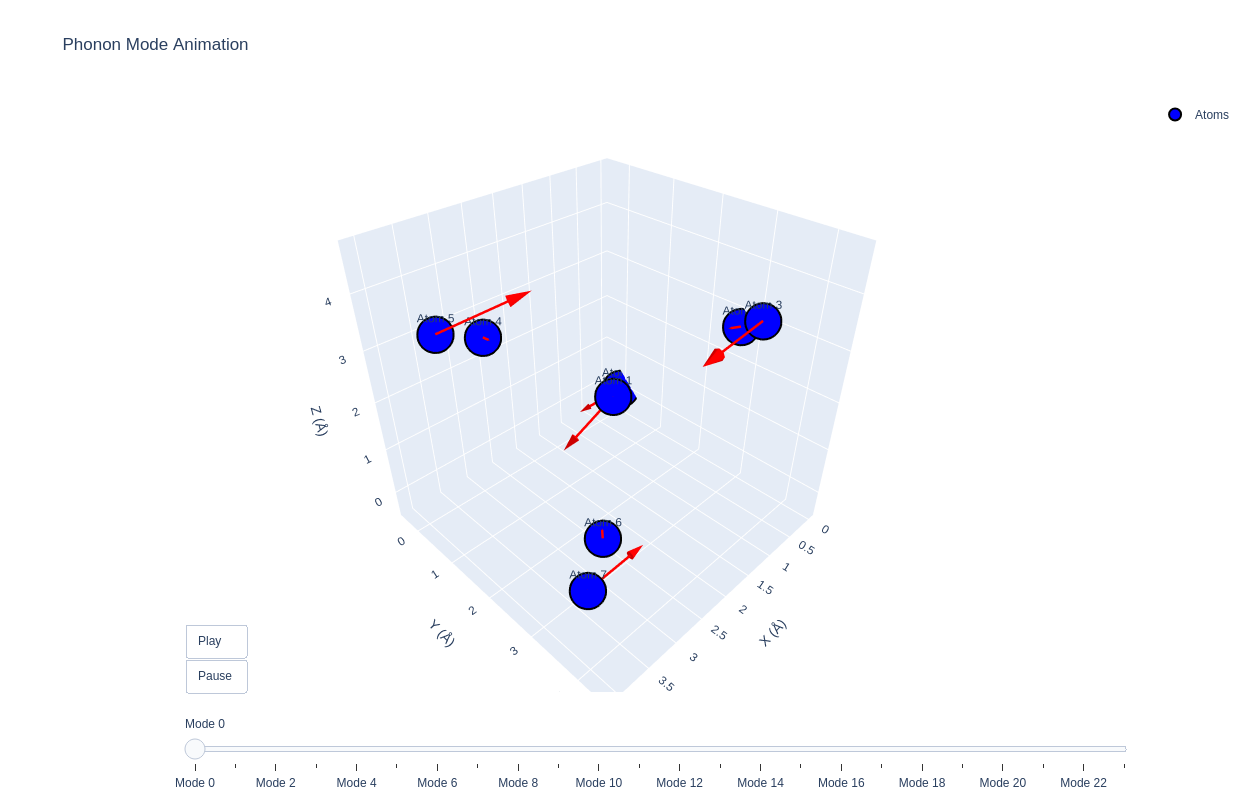

In [45]:
animate_modes_plotly(structure=structure_bulk, displacement_data=b2.copy(), scale_factor=2.0, frame_duration=500);

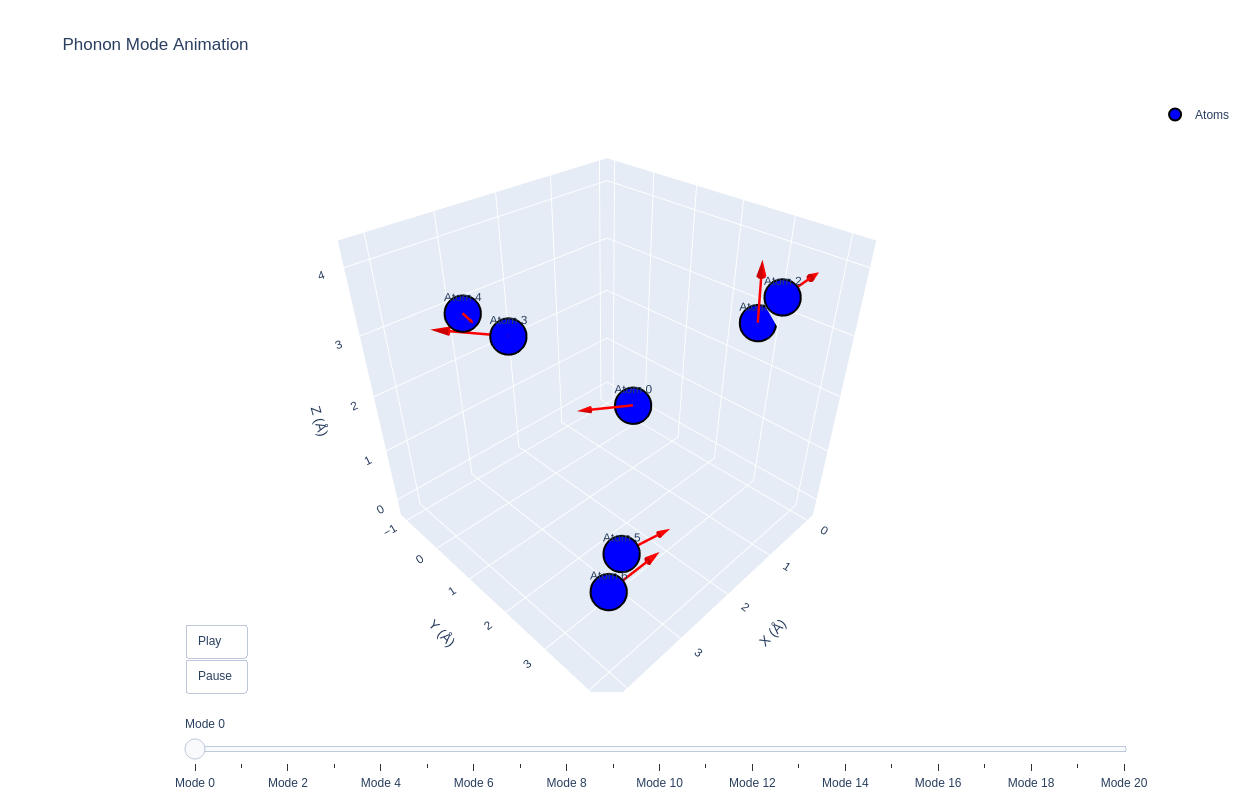

In [46]:
animate_modes_plotly(structure=structure_vacancy, displacement_data=b2_vacancy.copy(), scale_factor=2.0, frame_duration=500);